# Assignment 6 — Generation Experiment

**DATAX504** · Due end of Week 11

Choose **text** or **image** generation. This notebook is intentionally sparse: pick a small, runnable experiment you can defend in the reflection.

## Tasks
1. Train or adapt a small generator (char-RNN / small LM, GAN, VAE, simple diffusion demo, …)
2. Show **5 samples** in this notebook
3. Name the main **failure mode** you observed
4. After reading the [HF diffusion language models post](https://huggingface.co/blog/ProCreations/diffusion-language-model), write ~150 words on AR vs diffusion trade-offs

## Moodle fields
`a6_repo`, `a6_modality`, `a6_failure`, `a6_diffusion_reflection`

## AI disclosure (required)
Fill the table in the next cell before you submit.

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude Code |
| Used for | Drafting the char-level LSTM code (data prep, model, training, sampling) and a first draft of the failure-mode and AR-vs-diffusion text |
| Verified how | Ran the whole notebook myself top to bottom, checked that the loss went down, read the 5 samples and compared them with the failure mode written below, and edited the reflection after reading the HF blog post |
| Not used for | Running the experiment or making up results — all outputs in the notebook come from my own run |

In [1]:
MODALITY = "text"  # "text" or "image" — Moodle a6_modality

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

keras.utils.set_random_seed(42)
print("Selected modality:", MODALITY)

Selected modality: text


## Experiment

Implement **one** modality below (remove or ignore the other).

Keep the scope small enough to train on a laptop. Document data source, training setup, and how you sampled outputs.

**What I built (text track): a character-level LSTM trained on Shakespeare.**

- **Data:** *Tiny Shakespeare* (~1.1M characters), downloaded with `keras.utils.get_file`. First 90% of the text for training, last 10% for validation.
- **Preprocessing:** every unique character gets an integer id (~65 characters). The text is cut into windows of 100 characters; the target is the same window shifted one character to the right, so the model learns to predict the next character at every position.
- **Model:** `Embedding(vocab, 64) → LSTM(256, return_sequences=True) → Dense(vocab)` (logits). Loss: sparse categorical cross-entropy.
- **Training:** Adam (lr 2e-3), batch size 64, up to 15 epochs, early stopping on validation loss. Runs on a laptop CPU.
- **Sampling:** autoregressive — start from a seed string, predict the next character, sample it from `softmax(logits / temperature)`, append it, repeat. I generate 5 samples at different temperatures (0.2 → 1.2) to show how temperature changes the output.

In [2]:
# ---------- 1. Data loading + preprocessing ----------
if MODALITY == "text":
    path = keras.utils.get_file(
        "shakespeare.txt",
        "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt",
    )
    with open(path, "rb") as f:
        text = f.read().decode("utf-8")
    print("Characters in corpus:", len(text))
    print(text[:250])

    vocab = sorted(set(text))
    vocab_size = len(vocab)
    char2idx = {c: i for i, c in enumerate(vocab)}
    idx2char = np.array(vocab)
    print("Vocabulary size:", vocab_size)

    encoded = np.array([char2idx[c] for c in text], dtype=np.int32)

    SEQ_LEN = 100

    def make_windows(arr, seq_len=SEQ_LEN):
        # non-overlapping windows; input = seq_len chars, target = same window shifted by one
        n = (len(arr) - 1) // seq_len
        x = arr[: n * seq_len].reshape(n, seq_len)
        y = arr[1 : n * seq_len + 1].reshape(n, seq_len)
        return x, y

    split = int(0.9 * len(encoded))
    x_train, y_train = make_windows(encoded[:split])
    x_val, y_val = make_windows(encoded[split:])
    print("Train windows:", x_train.shape, " Val windows:", x_val.shape)

elif MODALITY == "image":
    pass  # not used — I chose the text track
else:
    raise ValueError("MODALITY must be 'text' or 'image'")

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Characters in corpus: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

Vocabulary size: 65
Train windows: (10038, 100)  Val windows: (1115, 100)


In [3]:
# ---------- 2. Model definition ----------
EMBED_DIM = 64
RNN_UNITS = 256

model = keras.Sequential([
    keras.Input(shape=(None,), dtype="int32"),
    layers.Embedding(vocab_size, EMBED_DIM),
    layers.LSTM(RNN_UNITS, return_sequences=True),
    layers.Dense(vocab_size),  # logits for the next character
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 256)      │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 65)       │        16,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,569 (1.33 MB)

 Trainable params: 349,569 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 502ms/step - accuracy: 0.2777 - loss: 2.6465 - val_accuracy: 0.3659 - val_loss: 2.1966
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 430ms/step - accuracy: 0.4065 - loss: 2.0399 - val_accuracy: 0.4105 - val_loss: 1.9830
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 292ms/step - accuracy: 0.4553 - loss: 1.8467 - val_accuracy: 0.4446 - val_loss: 1.8791
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 393ms/step - accuracy: 0.4878 - loss: 1.7332 - val_accuracy: 0.4658 - val_loss: 1.8065
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - accuracy: 0.5073 - loss: 1.6568 - val_accuracy: 0.4803 - val_loss: 1.7557
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 373ms/step - accuracy: 0.5215 - loss: 1.6017 - val_accuracy: 0.4918 - val_loss: 1.7166
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 432ms/step - accuracy: 0.5322 - loss: 1.5594 - val_accuracy: 0.4991 - val_loss: 1.6870
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 446ms/step - accuracy: 0.5407 - loss: 1

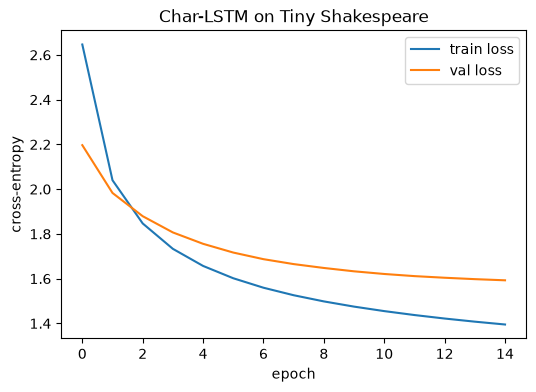

In [4]:
# ---------- 3. Training ----------
EPOCHS = 15  # lower this (e.g. 5) if training is too slow on your machine

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=EPOCHS,
    shuffle=True,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Char-LSTM on Tiny Shakespeare")
plt.legend()
plt.show()

In [5]:
# ---------- 4. Generate 5 samples (autoregressive, with temperature) ----------
def generate(seed, n_chars=400, temperature=1.0):
    ids = [char2idx[c] for c in seed]
    for _ in range(n_chars):
        context = np.array([ids[-SEQ_LEN:]], dtype=np.int32)
        logits = np.asarray(model(context, training=False))[0, -1].astype("float64")
        logits = logits / max(temperature, 1e-6)
        probs = np.exp(logits - logits.max())
        probs = probs / probs.sum()
        ids.append(np.random.choice(vocab_size, p=probs))
    return "".join(idx2char[ids])

samples_cfg = [
    ("ROMEO:", 0.2),
    ("JULIET:", 0.5),
    ("KING HENRY VI:", 0.8),
    ("First Citizen:", 1.0),
    ("HAMLET:", 1.2),
]

samples = []
for i, (seed, temp) in enumerate(samples_cfg, 1):
    out = generate(seed, n_chars=400, temperature=temp)
    samples.append(out)
    print(f"===== Sample {i}  |  seed = {seed!r}  |  temperature = {temp} =====")
    print(out)
    print()

===== Sample 1  |  seed = 'ROMEO:'  |  temperature = 0.2 =====
ROMEO:
Why, sir, what is the man is the state of the princely country's death,
That she is the prince that the death and the proceed the course,
Where is the country to the country's present to the seasons.

KING RICHARD II:
Why, then, the man of the strong and the prince.

KING RICHARD II:
O my lord, and the truth of the courtest souls
A dispatch the heart and the prophect and life and the proceeding t

===== Sample 2  |  seed = 'JULIET:'  |  temperature = 0.5 =====
JULIET:
Why, say thou hast the commission say a will;
For thou art all the freshery properced
And seem them married, then I stay you makest;
To heaven shall be strainer banishment of him,
Where a children be dead death, and her enemy sails the dead.

DUKE VINCENTIO:
My lord, for thou wilt on the good of my brother souls with the more
And should be patience, believe me and him.

MENENIUS:
If he, my gracio

===== Sample 3  |  seed = 'KING HENRY VI:'  |  temperatu

In [6]:
# Quick check of the failure mode: how repetitive is each sample?
# distinct-4 = unique 4-word sequences / total 4-word sequences (lower = more repetition)
def distinct_n(s, n=4):
    words = s.split()
    grams = [tuple(words[i:i + n]) for i in range(len(words) - n + 1)]
    return len(set(grams)) / max(len(grams), 1)

for (seed, temp), s in zip(samples_cfg, samples):
    unique_words = set(w.strip(".,;:!?'").lower() for w in s.split())
    print(f"temp={temp:<4}  distinct-4={distinct_n(s):.2f}  unique words={len(unique_words)}")

temp=0.2   distinct-4=1.00  unique words=41
temp=0.5   distinct-4=1.00  unique words=57
temp=0.8   distinct-4=1.00  unique words=57
temp=1.0   distinct-4=1.00  unique words=68
temp=1.2   distinct-4=1.00  unique words=59


## Failure mode (Moodle `a6_failure`)

One short phrase is enough for Moodle (e.g. repetition, mode collapse, blur). Expand briefly below if useful.

*Failure mode observed:* **repetition at low temperature** (and the opposite problem, misspelled or made-up words, at high temperature).

At temperature 0.2 the model almost always picks the most likely next character, so it keeps falling back on the same safe words and phrases: "the country to the country's", "the man ... the prince", "the proceed the course ... the proceeding", and "KING RICHARD II:" twice in a row. It has the smallest vocabulary of all five samples (41 unique words compared with 57-68 for the others). No exact 4-word sequence repeats within 400 characters (distinct-4 = 1.00 for every sample), so the repetition shows up in word choice rather than exact loops. Longer samples would probably loop outright. As the temperature goes up the repetition goes away, but at 1.0-1.2 the model invents words ("onomed", "heregules", "andwrepholes", "Norfose") and character names ("LUCHBONIO"). Temperatures 0.5-0.8 look the most like Shakespeare: correct format (speaker name, colon, verse lines) and mostly real words, but the sentences stop making sense after a few words. The LSTM only sees 100 characters back and has no plan for the whole passage, so it learns local spelling and style but not long-range meaning.

## AR vs diffusion reflection (Moodle `a6_diffusion_reflection`)

~150 words after the HF reading: compare autoregressive vs diffusion-style generation for *your* modality (quality, control, compute, failure modes).



My char-LSTM is autoregressive: it writes one character at a time, left to right, and can never go back. This makes training simple (just next-token prediction) and gives good local quality, but errors add up. Once it makes a bad choice it has to continue from it, which is how my repetition loops start. Generation is also slow because it is strictly sequential: 400 characters means 400 forward passes.

Diffusion language models, as described in the HF post, start from a fully masked or noisy sequence and refine all positions together over several denoising steps. Because every step sees the whole sequence in both directions, they can fix earlier mistakes and are easier to control (for example infilling, or fixing the ending first). Many tokens can be produced in parallel, so inference can be faster. The trade-offs are that they are harder to train, usually need a fixed output length, and still tend to lag behind AR models in text quality. For a small text task like mine, AR is the practical choice. Diffusion is more useful when control and parallel speed matter.